# Projeto 1

Modelo de entrega da questão 2.

Respeite as divisões em Markdown para facilitar a navegação no relatório.

## Questão 2: Resolvendo sistemas tridiagonais.

### Questão 2.1
Escreva, em Python ou Julia, uma função `solve_tridiag(A, b)` que recebe uma matriz quadrada $A$ e um vetor $b$ e retorna a solução do sistema $Ax = b$ (você pode supor que $A$ é inversível).

<u>Comentário:</u> A função `solve_tridiag` é uma implementação do método de Thomas, onde a mesma funciona do seguinte modo:

A função recebe a matriz tridiagonal A e o vetor b, e começa extraindo as três diagonais de A: a inferior (inf), a principal (diag) e a superior (sup), já que são os únicos valores que importam para o algoritmo.

A partir daí, a resolução do sistema acontece em duas etapas. Na primeira, o Forward Sweep, a função percorre as linhas de cima para baixo eliminando os elementos da diagonal inferior. A cada linha, calcula um multiplicador e o usa para zerar o elemento intruso, atualizando o pivô (diag) e o lado direito (b) correspondentes. No final dessa etapa, o sistema original virou um sistema triangular superior.

Na segunda etapa, o Back Substitution, a função resolve esse sistema triangular de baixo para cima. A última linha tem só uma incógnita e é resolvida de forma direta. Cada linha acima usa o valor já calculado da linha de baixo para encontrar a próxima incógnita. No final do loop, todas as posições de x estão preenchidas com a solução.

In [ ]:
def solve_tridiag(A, b):
    """
    resolve o sistema linear Ax = b pelo Método de Thomas.

    parâmetros
        A : lista de listas (n x n): matriz tridiagonal invertível
        b : lista de n floats: vetor do lado direito

    retorna
        x : lista de n floats: solução do sistema
    """

    n = len(b)

    if n == 1:
        return [b[0] / A[0][0]]
 
    # extrai as três diagonais de A
    inf  = [A[i][i-1] for i in range(1, n)]    # O(n-1) = O(n)
    diag = [A[i][i]   for i in range(n)]       # O(n)
    sup  = [A[i][i+1] for i in range(n-1)]     # O(n-1) 
 
    # criar cópias para não modificar os vetores originais
    sup_prime = [0.0] * (n - 1) 
    b_prime   = [0.0] * n
    x         = [0.0] * n
 
 
    # Forward Sweep (fatoração)
    sup_prime[0] = sup[0] / diag[0]  # super-diagonal
    b_prime[0]   = b[0]  / diag[0]
 
    for i in range(1, n - 1):   #O(n)
        denom        = diag[i] - inf[i-1] * sup_prime[i-1]
        sup_prime[i] = sup[i] / denom
        b_prime[i]   = (b[i] - inf[i-1] * b_prime[i-1]) / denom

    denom = diag[n-1] - inf[n-2] * sup_prime[n-2]
    b_prime[n-1] = (b[n-1] - inf[n-2] * b_prime[n-2]) / denom
 
    # Back Substitution (substituição reversa)
    x[n-1] = b_prime[n-1]
 
    for i in range(n - 2, -1, -1): # O(n-2 + 0 + 1) = O(n-1) = O(n)
        x[i] = b_prime[i] - sup_prime[i] * x[i+1]
 
    return x
 


### Questão 2.2
Verifique que sua função está correta, fazendo alguns testes.

<u>Comentário:</u> Como b é combinação linear das colunas de A, podemos fazer essa combinação e gerar b a partir de um x qualquer. 
Obter esse x é o propósito da função solve_tridiag!
Gerar A e b de forma aleatória não faz sentido no contexto desse problema,  por isso criei a função gerar_sistema_tridiag. 

As funções gerar_sistema_tridiag e comparar_solucoes são criadas apenas para fazer testes! 

<u>PS:</u> O x produzido por gerar_sistema_tridiag é a solução do sistema, mas esse x é usado apenas para comparar com o resultado de solve_tridiag (similar a um gabarito).

<u>PPS:</u> Como a comparação "==" não é precisa no python, achei necessário criar uma função `comparar_solucoes` que calcula o módulo da diferença de cada termo da solução caculada pela solução obtida por meio de `solve_tridiag`. Criei uma condição que diz essas soluções são iguais quando o módulo da diferença é "bem pequeno" (relativo, mas optei por definir esse erro como 1**(-6)).

In [4]:
import time
import random


# medição de tempo das matrizes geradas aleatoriamente usando o perf_counter
def medir_tridiag(func, A, b, repeticoes=10):
    tempos = []
    for _ in range(repeticoes):
        inicio = time.perf_counter() # mensurado com perf_counter
        func(A, b)
        fim = time.perf_counter()
        tempos.append(fim - inicio)
    return sum(tempos) / len(tempos)


def gerar_sistema_tridiag(n):
    # gera x
    x = [random.uniform(1, 5) for _ in range(n)]

    # monta matriz tridiagonal
    A = [[0]*n for _ in range(n)] #só zeros

    for i in range(n):
        A[i][i] = random.uniform(5, 10)  # diagonal dom

        if i > 0:
            A[i][i-1] = random.uniform(1, 3) #diagonal inf

        if i < n-1:
            A[i][i+1] = random.uniform(1, 3) #diagonal sup

    # calcula b = Ax
    b = [0]*n
    for i in range(n):
        for j in range(n):
            b[i] += A[i][j]*x[j]

    return A, b, x

def comparar_solucoes(x_calc, x_real, tol=1e-6):
    """ 
    retorna True se todas as componentes diferem menos que tol
    
    """
    return all(abs(x_calc[i] - x_real[i]) < tol for i in range(len(x_calc)))

def rodar_teste(tamanhos, repeticoes=10):

    for n in tamanhos:
        A, b, x_real = gerar_sistema_tridiag(n)

        m = len(A)

        # x calculado em solve_tridiag
        x_calc = solve_tridiag(A, b)

        # medição
        t_tridiag = medir_tridiag(solve_tridiag, A, b, repeticoes)
        iguais = comparar_solucoes(x_calc, x_real)

        # exibir no terminal
        print(f"\n=== A: {m}×{m}  |  b: {m}×{1} ===")
        print(f"{'perf_counter':<15} {'solve_tridiag':>20}")
        print(f"{'Função':<25} {'Tempo médio (s)':>15} {'Solução correta?':>16}")
        print("-" * 57)
        print(f"{'solve_tridiag':<25} {t_tridiag:>15.6f} {str(iguais):>16}")


tamanhos = [2, 3, 5, 10, 30, 50, 100, 200, 500, 1000, 2000, 5000, 10000]

rodar_teste(tamanhos, repeticoes=20)


=== A: 2×2  |  b: 2×1 ===
perf_counter           solve_tridiag
Função                    Tempo médio (s) Solução correta?
---------------------------------------------------------
solve_tridiag                    0.000012             True

=== A: 3×3  |  b: 3×1 ===
perf_counter           solve_tridiag
Função                    Tempo médio (s) Solução correta?
---------------------------------------------------------
solve_tridiag                    0.000014             True

=== A: 5×5  |  b: 5×1 ===
perf_counter           solve_tridiag
Função                    Tempo médio (s) Solução correta?
---------------------------------------------------------
solve_tridiag                    0.000020             True

=== A: 10×10  |  b: 10×1 ===
perf_counter           solve_tridiag
Função                    Tempo médio (s) Solução correta?
---------------------------------------------------------
solve_tridiag                    0.000060             True

=== A: 30×30  |  b: 30×1 ===
perf_co

### Questão 2.3
Qual é a complexidade computacional da sua função?

<u>Resposta:</u> Ao trabalhar só com as inf, diag e sup (diagonais inferior, principal e superior da matriz A, respectivamente), a função não precisa varrer as linhas inteiras da matriz. A extração dessas diagonais requer percorrer seus elementos uma só vez, o que tem custo O(n).

Na etapa de Forward Sweep (fatoração), o loop vai rodar n-1 vezes, e cada iteração dele faz um número fixo de operações. Logo, o trabalho por linha é O(1)*, e temos n linhas, então O(n) no total.

Já no Back Substitution (substituição reversa), é o mesmo raciocínio com n-1 iterações, cada uma com um número fixo de operações, mantendo o custo linear. 

Dessa forma, temos que a complexidade computacional da função `solve_tridiag` é O(n+n+n+n) = O(4n) e ele tem complexidade O(n). 

<u>PS:</u> No código da função (solve_tridiag), estão sinalizados as linhas de código com a complexidade mencionada. Note que esse é o custo computacional aproximado!

<u>PPS*:</u> Note que pela estrutura tridiagonal de A, ela possui 3 no máximo elementos não-nulos, o que implica que o trabalho por linha é O(1).


### Questão 2.4
A partir de que tamanho de matriz $A$ a função `solve_tridiag` se torna mais rápida do que a função `numpy.linalg.solve` (ou `\`, em Julia)?
Como você fez para chegar neste resultado?

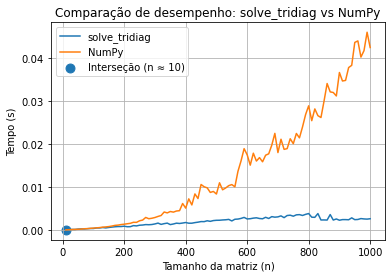

In [3]:
import numpy as np
import time
import os

# reduz variação do NumPy 
os.environ["OMP_NUM_THREADS"] = "1"


def solve_tridiag_np(A, b):
    return np.linalg.solve(A, b)


def benchmark(func, A, b, repeticoes=20):
    tempos = []
    for _ in range(repeticoes):
        inicio = time.perf_counter()
        func(A, b)
        fim = time.perf_counter()
        tempos.append(fim - inicio)
    return np.min(tempos)  # mais estável (reduz ruído)


def rodar_testes(inicio=10, fim=1000, passo=50, repeticoes=20):
    tamanhos, tempos_solve, tempos_np = [], [], []
    cruzamento = None

    for n in range(inicio, fim + 1, passo):
        A, b, x = gerar_sistema_tridiag(n)

        # converte UMA vez (remove ruído)
        A_np = np.array(A)
        b_np = np.array(b)

        # aquecimento
        solve_tridiag(A, b)
        np.linalg.solve(A_np, b_np)

        t_solve = benchmark(solve_tridiag, A, b, repeticoes)
        t_np = benchmark(lambda A, b: solve_tridiag_np(A_np, b_np), A, b, repeticoes)

        tamanhos.append(n)
        tempos_solve.append(t_solve)
        tempos_np.append(t_np)

        if t_solve < t_np and cruzamento is None:
            cruzamento = n

    return tamanhos, tempos_solve, tempos_np, cruzamento

tamanhos, tempos_solve, tempos_np, cruzamento = rodar_testes(10, 1000, 10, 30)


import matplotlib.pyplot as plt

def plotar_comparativo(tamanhos, tempos_solve, tempos_np, cruzamento):
    plt.figure()

    plt.plot(tamanhos, tempos_solve, label="solve_tridiag")
    plt.plot(tamanhos, tempos_np, label="NumPy")

    if cruzamento is not None:
        idx = tamanhos.index(cruzamento)
        x_cross = tamanhos[idx]
        y_cross = tempos_solve[idx]

        plt.scatter(x_cross, y_cross, s=80,
                    label=f"Interseção (n ≈ {cruzamento})")

    plt.xlabel("Tamanho da matriz (n)")
    plt.ylabel("Tempo (s)")
    plt.title("Comparação de desempenho: solve_tridiag vs NumPy")
    plt.legend()
    plt.grid()

    plt.show()

plotar_comparativo(tamanhos, tempos_solve, tempos_np, cruzamento)

<u>Comentário:</u> Para obter esse resultado, geramos sistemas lineares tridiagonais de tamanhos crescentes [0, 1000] e medimos o tempo de execução dos dois métodos: a função `solve_tridiag` e a função `numpy.linalg.solve`. Pra cada tamanho, o tempo foi calculado como o mínimo de várias execuções (padrão: 30), com o propósito de reduzir os ruídos experimentais. Em seguida, os tempos foram comparados e plotados, o que nos permite identificar o ponto em que `solve_tridiag` passa a ser mais eficiente que o NumPy.

Pelo gráfico, é possível ver que a função `solve_tridiag` tem crescimento linear como esperado, ao contrário da função `solve_tridiag_np`, que tem crescimento cúbico como esperado.